#  Image Classification Using Deep Learning — Part 1.2
---

> **A beginner-friendly notebook** exploring image classification on the **CIFAR-10 dataset** using PyTorch — covering data loading, transformation, batching, and visualization.

---

## What We'll Learn

| # | Topic | Tool/Concept |
|---|-------|-------------|
| 1 | Import Dataset | `torchvision.datasets` |
| 2 | Apply Transforms | `transforms.ToTensor()` |
| 3 | Batch Loading | `torch.utils.data.DataLoader` |
| 4 | Inspect Data Shape | Tensor shape analysis |
| 5 | Visualize Sample | `matplotlib` |

---

##  Libraries Used
- `torch` — core deep learning framework
- `torchvision` — datasets and image transforms
- `matplotlib` — image visualization

##  Step 1 — Import torchvision

`torchvision` is PyTorch's companion library for computer vision.
It provides ready-to-use **benchmark datasets** (CIFAR-10, MNIST, ImageNet),
**transforms** for preprocessing, and pretrained model architectures.

In [1]:
# Import datasets and transforms from torchvision
from torchvision import datasets, transforms


##  Step 2 — Load CIFAR-10 Dataset with Transform

### What is CIFAR-10?

**CIFAR-10** is a popular benchmark dataset containing **60,000 color images** across 10 classes.

| Property | Value |
|----------|-------|
| Total samples | 60,000 |
| Training samples | 50,000 |
| Test samples | 10,000 |
| Image size | 32 × 32 pixels |
| Classes | 10 |
| Color | RGB (3 channels) |

### Classes in CIFAR-10

| Label | Class |
|-------|-------|
| 0 | airplane  |
| 1 | automobile  |
| 2 | bird  |
| 3 | cat  |
| 4 | deer  |
| 5 | dog  |
| 6 | frog  |
| 7 | horse  |
| 8 | ship  |
| 9 | truck  |

### What does `transforms.ToTensor()` do?

It converts a PIL image into a **PyTorch tensor** and scales pixel values from
the range $[0, 255]$ to $[0.0, 1.0]$:

$$\text{tensor\_value} = \frac{\text{pixel\_value}}{255}$$

In [2]:
# Define transform: convert images to tensors (scales pixels to [0, 1])
transform = transforms.ToTensor()

# Download and load the CIFAR-10 training dataset
cifar_dataset = datasets.CIFAR10(
    root='./data',      # folder where data will be saved
    train=True,         # load training set (50,000 images)
    download=True,      # download if not already present
    transform=transform # apply the ToTensor transform
)

100%|██████████| 170M/170M [06:46<00:00, 419kB/s]




##  Step 3 — Create a DataLoader

### What is a DataLoader?

A `DataLoader` wraps a dataset and provides:
- **Batching** — groups samples into mini-batches
- **Shuffling** — randomizes order each epoch to improve training
- **Iteration** — easy `for` loop access to batches

### Why batch_size=10?

Instead of feeding all 50,000 images at once (too much memory),
we feed **10 images at a time**. This is called **mini-batch gradient descent**.

$$\text{Total batches} = \frac{50000}{10} = 5000 \text{ batches per epoch}$$



In [3]:
from torch.utils.data import DataLoader

# Wrap dataset in DataLoader for batching and shuffling
loader = DataLoader(
    cifar_dataset,
    batch_size=10,   # load 10 images per batch
    shuffle=True     # shuffle data every epoch
)



##  Step 4 — Inspect Batch Shape

We grab the **first batch** from the loader using `next(iter(...))` and inspect the tensor shapes.

### Understanding the shape: `[10, 3, 32, 32]`

| Dimension | Value | Meaning |
|-----------|-------|---------|
| `10` | batch size | 10 images per batch |
| `3` | channels | RGB = 3 channels (Red, Green, Blue) |
| `32` | height | 32 pixels tall |
| `32` | width | 32 pixels wide |

The labels shape `[10]` means one integer label (0–9) for each of the 10 images.

In [4]:
# Grab the first batch from the loader
images, labels = next(iter(loader))

# images shape: [batch_size, channels, height, width]
print(images.shape)

# labels shape: [batch_size] — one class label per image
print(labels.shape)

torch.Size([10, 3, 32, 32])
torch.Size([10])



##  Step 5 — Visualize a Random Sample

We pick a **random image** from the batch and display it using `matplotlib`.

### CIFAR-10 vs MNIST — Key Difference in Visualization

| | MNIST | CIFAR-10 |
|-|-------|----------|
| Channels | 1 (Grayscale) | 3 (RGB) |
| Shape | `[1, 28, 28]` | `[3, 32, 32]` |
| Display method | `squeeze()` + `cmap='gray'` | `permute(1, 2, 0)` |

PyTorch stores images as `[C, H, W]` but matplotlib expects `[H, W, C]`,
so we use `.permute(1, 2, 0)` to reorder the dimensions.

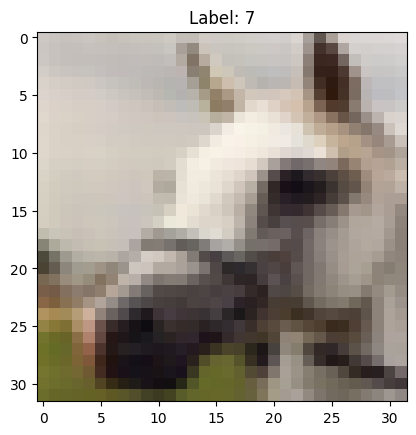

In [11]:
import random
import matplotlib.pyplot as plt

# Pick a random index from the batch (0 to 9)
random_idx = random.randint(0, 9)
image = images[random_idx]
label = labels[random_idx]

# permute: [3, 32, 32] → [32, 32, 3] so matplotlib can display RGB correctly
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {label.item()}")
plt.show()



##  Conclusion & Key Takeaways

### Summary of What We Did

| Step | Action | Key Detail |
|------|--------|------------|
| Step 1 | Imported torchvision | Access to datasets & transforms |
| Step 2 | Loaded CIFAR-10 dataset | 50,000 training images, 32×32 RGB |
| Step 3 | Created DataLoader | batch_size=10, shuffle=True |
| Step 4 | Inspected tensor shape | `[10, 3, 32, 32]` — batch × channel × H × W |
| Step 5 | Visualized a sample | Random image with true class label |

---

###  Key Takeaways

1. **`transforms.ToTensor()`** converts images to tensors and normalizes pixels to $[0, 1]$
2. **DataLoader** handles batching and shuffling — essential for efficient training
3. **CIFAR-10 tensor shape** `[B, C, H, W]` is the standard PyTorch format
4. **RGB images** have 3 channels — unlike MNIST's single grayscale channel
5. **`.permute(1, 2, 0)`** is needed to convert `[C, H, W]` → `[H, W, C]` for matplotlib

